# 06 — Fairness

The question is **not** whether the participants preferred their own background. They did, it is in
the data, and it is descriptive. The question is whether **the engine** disadvantages a group, and
whether it *amplifies* that preference beyond what the data already contains.

**The mapping, fixed once for the whole notebook.**

| Symbol | Here |
|---|---|
| Y = 1 | the pair matched |
| Ŷ = 1 | the pair is in the top decile, so the app would show it |
| D | the protected attribute, D = 1 the protected group |

Ŷ is a top-K and not a 0.5 threshold, for the reason given in 04: no pair ever scores above 0.5, so a
threshold classifier predicts zero everywhere and every confusion-matrix metric is degenerate. All
the tests below are on the list the app shows.

**Two definitions of D**, treated separately:

1. **A person's ethnicity**, one group against all the others, at the level of the 8,368 person-pair
   rows — each pair contributes its two participants.
2. **A mixed pair against a same-background pair**, at the level of the 4,184 pairs.

In [1]:
%matplotlib inline

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.stats.multitest import multipletests
from xgboost import XGBClassifier

if not Path("data").is_dir():
    os.chdir("..")

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

SEED, K, ALPHA = 42, 0.10, 0.05
RACE = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native American", 6: "Other"}

table = pd.read_csv("data/processed/model_table.csv")
oof = pd.read_csv("data/processed/oof_predictions.csv")

MODEL = "logit"          # the two-stage white box, our recommended model
oof["shown"] = (oof[MODEL] >= oof[MODEL].quantile(1 - K)).astype(int)
print(f"{oof.shown.sum()} pairs shown out of {len(oof)}; {oof.match.mean():.3f} base match rate")

419 pairs shown out of 4184; 0.165 base match rate


In [2]:
# One row per participant per date: the unit for anything defined on a person's ethnicity.
sides = pd.concat([
    pd.DataFrame({"pair": table.pair, "wave": table.wave, "match": table.match,
                  "shown": oof.shown, "race": table.her_race, "female": 1}),
    pd.DataFrame({"pair": table.pair, "wave": table.wave, "match": table.match,
                  "shown": oof.shown, "race": table.his_race, "female": 0})], ignore_index=True)
sides["group"] = sides.race.map(RACE)
sides = sides.dropna(subset=["group"])

GROUPS = sides.group.value_counts()
print(GROUPS.to_string())
print(f"\n{len(sides)} person-pair rows, {int(2 * len(table)) - len(sides)} dropped for a missing ethnicity")

group
White     4722
Asian     1978
Latino     664
Other      521
Black      420

8305 person-pair rows, 63 dropped for a missing ethnicity


Five groups, and they are nothing like the same size: 4,722 person-pair rows for White participants
against 420 for Black ones. A test on the small groups has little power, so a non-significant result
there means "we cannot tell", not "there is no gap". Every table below carries the group size for
that reason.

## 1. Statistical parity

Pr(Ŷ = 1 | D = 1) = Pr(Ŷ = 1 | D = 0). Each group against all the others, two-proportion z-test.

In [3]:
def two_proportion_z(shown_a, n_a, shown_b, n_b):
    # Pooled variance, the usual form for a difference of proportions under the null.
    p_a, p_b = shown_a / n_a, shown_b / n_b
    pooled = (shown_a + shown_b) / (n_a + n_b)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / se
    return p_a, p_b, z, 2 * stats.norm.sf(abs(z))

rows = []
for group in GROUPS.index:
    inside, outside = sides[sides.group == group], sides[sides.group != group]
    rate, other, z, p = two_proportion_z(inside.shown.sum(), len(inside),
                                         outside.shown.sum(), len(outside))
    rows.append({"group": group, "n": len(inside), "selection rate": rate,
                 "rate elsewhere": other, "difference (pts)": 100 * (rate - other), "z": z, "p-value": p})

parity = pd.DataFrame(rows).set_index("group").sort_values("difference (pts)")
parity.round(4)

,n,selection rate,rate elsewhere,difference (pts),z,p-value
group,,,,,,
Asian,1978,0.0576,0.1128,-5.5216,-7.1543,0.0000
White,4722,0.0974,0.1027,-0.5291,-0.7971,0.4254
Latino,664,0.1310,0.0970,3.4047,2.8089,0.0050
Other,521,0.1631,0.0955,6.7696,4.9931,0.0000
Black,420,0.1952,0.0946,10.0628,6.7071,0.0000


In [4]:
mixed = table.samerace == 0
rate, other, z, p = two_proportion_z(oof.shown[mixed].sum(), int(mixed.sum()),
                                     oof.shown[~mixed].sum(), int((~mixed).sum()))
pair_parity = pd.DataFrame([{"comparison": "mixed pair vs same background", "n mixed": int(mixed.sum()),
                             "selection rate, mixed": rate, "selection rate, same": other,
                             "difference (pts)": 100 * (rate - other), "z": z, "p-value": p}]).set_index("comparison")
pair_parity.round(4)

,n mixed,"selection rate, mixed","selection rate, same",difference (pts),z,p-value
comparison,,,,,,
mixed pair vs same background,2526,0.0867,0.1206,-3.3929,-3.5759,0.0003


The gaps are large and they go both ways. Asian participants appear in 5.8% of the shown pairs
against 11.3% for everyone else — they are recommended roughly half as often. Black participants are
at 19.5%, twice the rate of the rest. White participants, the majority, sit exactly at the average.
Mixed pairs are shown 3.4 points less often than same-background pairs.

None of this is yet evidence that the model is at fault: a group can differ on things the engine is
entitled to use. That is what the next section separates.

## 2. Conditional statistical parity

Raw parity does not distinguish a biased engine from a group that differs on things the engine is
entitled to use. Conditional parity asks the sharper question: Ŷ ⊥ D | X_c, where X_c is the set of
**legitimate** variables.

We commit to four, and the choice has to be defended rather than assumed:

| Variable | Why it is legitimate |
|---|---|
| `other_selfattr` | how attractive the partner rates themselves — the single thing a dating app exists to act on |
| `other_selfsinc` | sincerity, same argument |
| `interests` | the correlation between the two activity profiles: a property of the pair, not of a person |
| `agegap` | the age difference, which both sides state a preference over |

None of them is ethnicity, and none is an obvious proxy for it — we check that claim in section 5.
The four are combined into one score, cut into four strata of equal size, and the Cochran–Mantel–
Haenszel test then asks whether D and Ŷ are still associated **inside** the strata.

In [5]:
LEGITIMATE = ["other_selfattr", "other_selfsinc", "interests", "agegap"]

legitimate_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                 LogisticRegression(max_iter=3000))
pair_legitimate = pd.DataFrame({
    "other_selfattr": table[["her_selfattr", "his_selfattr"]].mean(axis=1),
    "other_selfsinc": table[["her_selfsinc", "his_selfsinc"]].mean(axis=1),
    "interests": table.interests, "agegap": table.agegap})
legitimate_model.fit(pair_legitimate, table.match)
pair_stratum = pd.qcut(legitimate_model.predict_proba(pair_legitimate)[:, 1], 4, labels=False)
stratum = pd.concat([pd.Series(pair_stratum)] * 2, ignore_index=True)[sides.index]

print("pairs per stratum:", np.bincount(pair_stratum))
print("match rate per stratum:", table.groupby(pair_stratum).match.mean().round(3).to_list())

pairs per stratum: [1046 1046 1046 1046]
match rate per stratum: [0.12, 0.157, 0.166, 0.216]


In [6]:
def cochran_mantel_haenszel(flag, shown, strata):
    # One 2x2 table of (in the group / not) x (shown / not) per stratum, then the CMH test.
    tables = []
    for s in np.unique(strata):
        here = strata == s
        tables.append(np.array([[int(((flag == 1) & (shown == 1) & here).sum()),
                                 int(((flag == 1) & (shown == 0) & here).sum())],
                                [int(((flag == 0) & (shown == 1) & here).sum()),
                                 int(((flag == 0) & (shown == 0) & here).sum())]]))
    result = StratifiedTable(tables)
    return result.oddsratio_pooled, result.test_null_odds().pvalue

rows = []
for group in GROUPS.index:
    ratio, p = cochran_mantel_haenszel((sides.group == group).to_numpy(), sides.shown.to_numpy(),
                                       stratum.to_numpy())
    rows.append({"D": group, "common odds ratio": ratio, "CMH p-value": p})
ratio, p = cochran_mantel_haenszel(mixed.to_numpy().astype(int), oof.shown.to_numpy(), pair_stratum)
rows.append({"D": "mixed pair", "common odds ratio": ratio, "CMH p-value": p})

conditional = pd.DataFrame(rows).set_index("D")
conditional.round(4)

,common odds ratio,CMH p-value
D,,
White,0.8877,0.1126
Asian,0.5374,0.0000
Latino,1.4508,0.0025
Other,1.7096,0.0000
Black,2.1216,0.0000
mixed pair,0.6930,0.0005


Six tests, plus the six in section 1, so we control the false discovery rate before reading any of
them. Benjamini-Hochberg over the whole family — this is our addition, the course states the tests
one at a time.

In [7]:
verdicts = pd.DataFrame({
    "n": list(parity.n) + [int(mixed.sum())],
    "difference (pts)": list(parity["difference (pts)"]) + [pair_parity["difference (pts)"].iloc[0]],
    "parity p": list(parity["p-value"]) + [pair_parity["p-value"].iloc[0]]},
    index=list(parity.index) + ["mixed pair"])
verdicts["conditional p"] = conditional["CMH p-value"].reindex(verdicts.index).to_numpy()

for column in ["parity p", "conditional p"]:
    verdicts[column + " (BH)"] = multipletests(verdicts[column], alpha=ALPHA, method="fdr_bh")[1]

def traffic_light(row):
    raw = row["parity p (BH)"] < ALPHA
    conditioned = row["conditional p (BH)"] < ALPHA
    if raw and conditioned:
        return "RED — the gap survives the legitimate variables"
    if raw:
        return "AMBER — gap explained by the legitimate variables"
    return "GREEN — no detectable gap"

verdicts["verdict"] = verdicts.apply(traffic_light, axis=1)
verdicts.to_csv("reports/tables/06_parity_verdicts.csv")
verdicts.round(4)

,n,difference (pts),parity p,conditional p,parity p (BH),conditional p (BH),verdict
Asian,1978,-5.5216,0.0000,0.0000,0.0000,0.0000,RED — the gap survives the legitimate variables
White,4722,-0.5291,0.4254,0.1126,0.4254,0.1126,GREEN — no detectable gap
Latino,664,3.4047,0.0050,0.0025,0.0060,0.0030,RED — the gap survives the legitimate variables
Other,521,6.7696,0.0000,0.0000,0.0000,0.0000,RED — the gap survives the legitimate variables
Black,420,10.0628,0.0000,0.0000,0.0000,0.0000,RED — the gap survives the legitimate variables
mixed pair,2526,-3.3929,0.0003,0.0005,0.0005,0.0007,RED — the gap survives the legitimate variables


This is the answer to the client's question, and it is not the comfortable one. **Four of the six
gaps survive the legitimate variables.** Inside strata of comparable attractiveness, sincerity,
shared interests and age gap, an Asian participant still has about half the odds of being
recommended (common odds ratio 0.54) and a Black participant about twice (2.12). Mixed pairs keep an
odds ratio of 0.69.

Only White participants come out green, which is what a majority group usually does: the comparison
"White against everyone else" is the one where the two sides look most alike.

So the answer is not "the participants were biased and the model reflects it". The model produces
gaps that the legitimate variables do not explain.

## 3. Amplification

Parity asks whether a group is shown less. Amplification asks something the course does not cover and
the client should care about more: does the engine **exaggerate** the same-background preference that
is already in the data?

The ratio is the share of same-background pairs among the pairs the app would show, divided by their
share among the pairs that actually matched. Above 1, the recommendation is more segregated than
reality. This is our extension.

In [8]:
def amplification(frame, shown_column="shown"):
    same = table.samerace.to_numpy()[frame.index]
    shown, matched = frame[shown_column].to_numpy() == 1, frame.match.to_numpy() == 1
    return same[shown].mean() / same[matched].mean()

def bootstrap_ci(frame, metric, n_boot=1000, stratify_by="wave", seed=SEED):
    # Rows resampled within waves, the same function as in 04 and 05.
    rng = np.random.default_rng(seed)
    blocks = [g.index.to_numpy() for _, g in frame.groupby(stratify_by)]
    draws = [metric(frame.loc[np.concatenate([rng.choice(b, len(b), True) for b in blocks])])
             for _ in range(n_boot)]
    return metric(frame), *np.percentile(draws, [2.5, 97.5])

point, low, high = bootstrap_ci(oof, amplification)
print(f"same-background share among shown pairs:   {table.samerace[oof.shown == 1].mean():.3f}")
print(f"same-background share among matched pairs: {table.samerace[oof.match == 1].mean():.3f}")
print(f"amplification ratio: {point:.3f}   95% CI [{low:.3f}, {high:.3f}]")

same-background share among shown pairs:   0.477
same-background share among matched pairs: 0.410
amplification ratio: 1.164   95% CI [1.033, 1.297]


In [9]:
rows = []
for k in [0.05, 0.10, 0.20]:
    frame = oof.assign(shown=(oof[MODEL] >= oof[MODEL].quantile(1 - k)).astype(int))
    point, low, high = bootstrap_ci(frame, amplification, n_boot=500)
    rows.append({"shown": f"top {k:.0%}", "amplification": round(point, 3),
                 "95% CI": f"[{low:.3f}, {high:.3f}]",
                 "amplifies": "yes" if low > 1 else "not detectable"})

pd.DataFrame(rows).set_index("shown")

,amplification,95% CI,amplifies
shown,,,
top 5%,1.138,"[0.950, 1.318]",not detectable
top 10%,1.164,"[1.037, 1.287]",yes
top 20%,1.183,"[1.079, 1.299]",yes


Same-background pairs are 41% of the pairs that actually matched, and 48% of the pairs the app would
show. The ratio is **1.16, with a bootstrap interval of [1.03, 1.30]** — above 1, so the engine is
measurably more segregated than the reality it was trained on. The effect grows with the length of
the list and disappears into the noise at the top 5%, where there are only 209 pairs.

This is the single number to put on the slide. It is not that the engine invented a preference; it
is that it sharpened one.

## 4. Mitigation

Four models, refitted on the same folds with the same pipeline, differing only in what they are
allowed to see about ethnicity. Panel A refits; panel B keeps the full model and neutralises the
ethnicity columns at prediction time, setting everyone to the majority category — which is what a
team would do if retraining were not an option.

In [10]:
TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

def decision_view(tab, decider, drop=()):
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age
    view["female"] = int(decider == "her")
    return view.drop(columns=[c for c in drop if c in view.columns])

def two_stage(categorical):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), categorical)], remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"))

VARIANTS = {
    "full model": (),
    "without raceclash": ("raceclash",),
    "without ethnicity": ("self_race", "other_race"),
    "without either": ("self_race", "other_race", "raceclash"),
    "unawareness": ("self_race", "other_race", "raceclash", "samerace",
                    "self_racepref", "other_racepref", "racepref_max")}

def refit_scores(drop):
    hers, his = decision_view(table, "her", drop), decision_view(table, "his", drop)
    categorical = [c for c in SIDE_CATEGORICAL if c in hers.columns]
    scores = np.empty(len(table))
    for k in sorted(table.fold.unique()):
        train, test = (table.fold != k).to_numpy(), (table.fold == k).to_numpy()
        model = two_stage(categorical).fit(
            pd.concat([hers[train], his[train]], ignore_index=True),
            pd.concat([table.her_dec[train], table.his_dec[train]], ignore_index=True))
        scores[test] = (model.predict_proba(hers[test])[:, 1] * model.predict_proba(his[test])[:, 1])
    return scores

In [11]:
def group_parity(shown):
    # Selection rate of each ethnic group against the rest, on the person-pair rows.
    person = pd.concat([pd.Series(shown)] * 2, ignore_index=True)[sides.index]
    out = {}
    for group in GROUPS.index:
        inside, outside = person[sides.group == group], person[sides.group != group]
        out[group] = two_proportion_z(inside.sum(), len(inside), outside.sum(), len(outside))[3]
    return pd.Series(out)

def evaluate(scores, k=K):
    shown = (scores >= np.quantile(scores, 1 - k)).astype(int)
    by_group = group_parity(shown)
    _, _, _, p_mixed = two_proportion_z(shown[mixed].sum(), int(mixed.sum()),
                                        shown[~mixed].sum(), int((~mixed).sum()))
    return {"worst group": by_group.idxmin(), "parity p (that group)": by_group.min(),
            "parity p (mixed pairs)": p_mixed,
            "amplification": amplification(oof.assign(shown=shown)),
            "PR-AUC": average_precision_score(table.match, scores),
            "top decile": table.match[scores >= np.quantile(scores, 0.9)].mean()}

panel_a = pd.DataFrame({name: evaluate(refit_scores(drop)) for name, drop in VARIANTS.items()}).T
panel_a.index.name = "Panel A — refitted"
panel_a.round(4)

,worst group,parity p (that group),parity p (mixed pairs),amplification,PR-AUC,top decile
Panel A — refitted,,,,,,
full model,Asian,0.0,0.000519,1.157982,0.228165,0.298329
without raceclash,Asian,0.0,0.000004,1.221991,0.222615,0.279236
without ethnicity,White,0.0,0.0,1.350009,0.218612,0.250597
without either,White,0.000006,0.0,1.291819,0.216566,0.252983
unawareness,White,0.008855,0.058591,1.070697,0.210357,0.24821


In [12]:
hers_full, his_full = decision_view(table, "her"), decision_view(table, "his")

def neutralised(frame, what):
    # No refit: the model still has its ethnicity coefficients, we just feed it a neutral profile.
    out = frame.copy()
    if "race" in what:
        out["self_race"] = out["other_race"] = 2.0          # the majority category
    if "raceclash" in what:
        out["raceclash"] = 0.0
    return out

def blind_scores(what):
    scores = np.empty(len(table))
    for k in sorted(table.fold.unique()):
        train, test = (table.fold != k).to_numpy(), (table.fold == k).to_numpy()
        model = two_stage(SIDE_CATEGORICAL).fit(
            pd.concat([hers_full[train], his_full[train]], ignore_index=True),
            pd.concat([table.her_dec[train], table.his_dec[train]], ignore_index=True))
        scores[test] = (model.predict_proba(neutralised(hers_full[test], what))[:, 1]
                        * model.predict_proba(neutralised(his_full[test], what))[:, 1])
    return scores

PANEL_B = {"full model": (), "ethnicity neutralised": ("race",),
           "raceclash neutralised": ("raceclash",), "both neutralised": ("race", "raceclash")}
panel_b = pd.DataFrame({name: evaluate(blind_scores(what)) for name, what in PANEL_B.items()}).T
panel_b.index.name = "Panel B — neutralised, no refit"
pd.concat([panel_a, panel_b]).to_csv("reports/tables/06_mitigation.csv")
panel_b.round(4)

,worst group,parity p (that group),parity p (mixed pairs),amplification,PR-AUC,top decile
"Panel B — neutralised, no refit",,,,,,
full model,Asian,0.0,0.000349,1.163801,0.227097,0.298329
ethnicity neutralised,White,0.0,0.0,1.594407,0.217246,0.245823
raceclash neutralised,Black,0.0,0.000148,0.75647,0.226056,0.281623
both neutralised,White,0.008951,0.011636,1.105611,0.213769,0.25537


The table says the obvious fix does not work, and this is the most useful result in the notebook.

**Removing ethnicity makes the segregation worse, not better.** Amplification goes from 1.16 to 1.35
when the one-hot ethnicity columns are dropped, and to 1.57 when they are neutralised without a
refit. Deprived of the column, the model leans harder on whatever correlates with it — and it pays
five points of top-decile match rate for the privilege (0.298 to 0.251).

**Only the full unawareness variant moves the needle**, dropping ethnicity, `raceclash`, `samerace`
and both preference columns at once: amplification falls to 1.07 and the mixed-pair gap stops being
significant. It costs the most performance of any variant, 0.298 to 0.248 in the top decile.

That is the trade-off to hand the client, stated honestly: roughly five points of match rate in
exchange for a recommendation that no longer sharpens the same-background preference.

In [13]:
mitigated = refit_scores(VARIANTS["unawareness"])
full = refit_scores(VARIANTS["full model"])
per_thousand = lambda s: 1000 * table.match[s >= np.quantile(s, 1 - K)].mean()
print(f"full model:     {per_thousand(full):.0f} matches per 1,000 recommendations")
print(f"unawareness:    {per_thousand(mitigated):.0f}")
print(f"price of removing the amplification: {per_thousand(full) - per_thousand(mitigated):.0f} "
      f"matches per 1,000, or that many times the value of one match")

full model:     298 matches per 1,000 recommendations
unawareness:    248
price of removing the amplification: 50 matches per 1,000, or that many times the value of one match


## 5. Why removing the column is not enough

Fairness through unawareness assumes that a model which never sees ethnicity cannot act on it. The
test of that assumption is direct: try to predict ethnicity from everything that is left.

In [14]:
left = decision_view(table, "her", VARIANTS["unawareness"])
target = table.her_race.notna()
proxy = make_pipeline(
    ColumnTransformer([("categories", OneHotEncoder(min_frequency=0.03,
                        handle_unknown="infrequent_if_exist", sparse_output=False),
                        [c for c in SIDE_CATEGORICAL if c in left.columns])], remainder="passthrough"),
    SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=3000))

recovered = []
for group in GROUPS.index:
    y = (table.her_race.map(RACE) == group).astype(int)[target]
    scores = np.empty(int(target.sum()))
    folds = table.fold[target].to_numpy()
    for k in np.unique(folds):
        train, test = folds != k, folds == k
        proxy.fit(left[target][train], y[train])
        scores[test] = proxy.predict_proba(left[target][test])[:, 1]
    recovered.append({"group": group, "share": y.mean(),
                      "AUC predicting it without any ethnicity column": roc_auc_score(y, scores)})

recovered = pd.DataFrame(recovered).set_index("group")
recovered.to_csv("reports/tables/06_proxy_recovery.csv")
recovered.round(3)

,share,AUC predicting it without any ethnicity column
group,,
White,0.533,0.651
Asian,0.252,0.664
Latino,0.097,0.510
Other,0.059,0.469
Black,0.058,0.516


Ethnicity is recoverable at **AUC 0.66** for White and Asian participants from a table that contains
no ethnicity column, no `samerace`, no `raceclash` and no preference for background. Income
missingness, how often someone goes out, and self-rated attractiveness carry it.

For the three small groups the AUC is near 0.5, but that is a statement about 420 rows, not about
the absence of a proxy.

So unawareness is not a defence. The model can act on ethnicity without being shown it, which is
exactly what the amplification number above shows it doing.

## 6. Equivalence: is the gap small enough to call it none? (TOST)

A non-significant difference is not evidence of equality — it can simply mean a small sample. The
two one-sided tests turn the question round: the null is that the gap is **at least** δ, and
rejecting it on both sides is evidence that the gap is smaller than δ.

z^L = (p̂₁ − p̂₂ + δ) / σ̂, with σ̂² = p̂₁(1−p̂₁)/n₁ + p̂₂(1−p̂₂)/n₂ — the variance is **not** pooled,
because under the equivalence null the two proportions are not assumed equal.

We set **δ = 5 percentage points** of selection rate, for two reasons. First the four-fifths rule: at a 10% selection rate, a group at 8% is at the
edge of adverse impact, so 2 points is already meaningful and 5 is beyond it. Second the noise floor:
the bootstrap interval on the top-decile match rate is about 8 points wide, so a tolerance below
about 3 points is smaller than anything we can resolve. δ = 3 and δ = 10 are reported next to it.

In [15]:
def tost(shown_a, n_a, shown_b, n_b, delta, alpha=ALPHA):
    p_a, p_b = shown_a / n_a, shown_b / n_b
    se = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)   # unpooled
    z_low, z_high = (p_a - p_b + delta) / se, (p_a - p_b - delta) / se
    critical = stats.t.ppf(1 - alpha, n_a + n_b - 2)
    return z_low, z_high, (z_low > critical) and (z_high < -critical)

rows = []
for delta in [0.03, 0.05, 0.10]:
    for group in GROUPS.index:
        inside, outside = sides[sides.group == group], sides[sides.group != group]
        z_low, z_high, equivalent = tost(inside.shown.sum(), len(inside),
                                         outside.shown.sum(), len(outside), delta)
        rows.append({"delta": f"{delta:.0%}", "D": group, "n": len(inside),
                     "z lower": z_low, "z upper": z_high,
                     "equivalent": "yes" if equivalent else "cannot conclude"})
    z_low, z_high, equivalent = tost(oof.shown[mixed].sum(), int(mixed.sum()),
                                     oof.shown[~mixed].sum(), int((~mixed).sum()), delta)
    rows.append({"delta": f"{delta:.0%}", "D": "mixed pair", "n": int(mixed.sum()),
                 "z lower": z_low, "z upper": z_high,
                 "equivalent": "yes" if equivalent else "cannot conclude"})

equivalence = pd.DataFrame(rows).set_index(["delta", "D"])
equivalence.to_csv("reports/tables/06_equivalence.csv")
equivalence.round(3)

n  z lower  z upper       equivalent
delta D                                                  
3%    White       4722    3.711   -5.300              yes
      Asian       1978   -3.833  -12.953  cannot conclude
      Latino       664    4.735    0.299  cannot conclude
      Other        521    5.911    2.281  cannot conclude
      Black        420    6.658    3.600  cannot conclude
      mixed pair  2526   -0.402   -6.548  cannot conclude
5%    White       4722    6.714   -8.303              yes
      Asian       1978   -0.793  -15.993  cannot conclude
      Latino       664    6.214   -1.179  cannot conclude
      Other        521    7.121    1.071  cannot conclude
      Black        420    7.677    2.580  cannot conclude
      mixed pair  2526    1.646   -8.596              yes
10%   White       4722   14.223  -15.812              yes
      Asian       1978    6.807  -23.593              yes
      Latino       664    9.911   -4.876              yes
      Other        521   10.147   -1.955              yes
      Black        420   10.225    0.032  cannot conclude
      mixed pair  2526    6.767  -13.717              yes

Only White participants are equivalent at δ = 3 points, and only White and mixed pairs at δ = 5. For
the three small groups the test cannot conclude at any tolerance below 10 points — with 420 to 664
rows there is not enough data to certify equality, whatever the point estimate says.

This is the honest reading of "no significant difference" for a small group: not a clean bill of
health, an absence of power.

## 7. Equal opportunity and calibration (secondary)

Equal opportunity is Ŷ ⊥ D | Y: among the pairs that **did** match, is the engine as likely to have
shown them for one group as for another? That is the error the client pays for — a real match the
app never surfaced.

In [16]:
matched = sides[sides.match == 1]
rows = []
for group in GROUPS.index:
    inside, outside = matched[matched.group == group], matched[matched.group != group]
    rate, other, z, p = two_proportion_z(inside.shown.sum(), len(inside), outside.shown.sum(), len(outside))
    rows.append({"group": group, "matches in the data": len(inside),
                 "share of them shown": rate, "elsewhere": other,
                 "difference (pts)": 100 * (rate - other), "p-value": p})

opportunity = pd.DataFrame(rows).set_index("group").sort_values("difference (pts)")
opportunity.to_csv("reports/tables/06_equal_opportunity.csv")
opportunity.round(4)

,matches in the data,share of them shown,elsewhere,difference (pts),p-value
group,,,,,
Asian,267,0.1049,0.2011,-9.6223,0.0003
White,788,0.1612,0.2111,-4.9905,0.0183
Latino,123,0.2195,0.1786,4.0912,0.2623
Black,85,0.3412,0.1717,16.9436,0.0001
Other,103,0.3689,0.1671,20.1869,0.0000


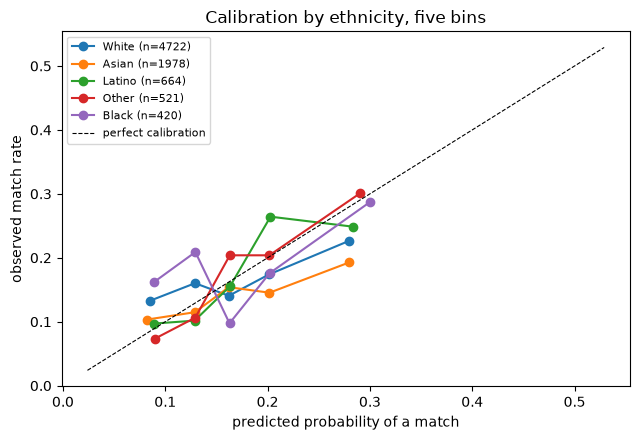

In [17]:
person_score = pd.concat([oof[MODEL], oof[MODEL]], ignore_index=True)[sides.index]
bins = pd.qcut(person_score, 5, labels=False)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group in GROUPS.index:
    here = sides.group == group
    ax.plot(person_score[here].groupby(bins[here]).mean(),
            sides.match[here].groupby(bins[here]).mean(), "o-", label=f"{group} (n={GROUPS[group]})")
limits = [person_score.min(), person_score.max()]
ax.plot(limits, limits, "k--", linewidth=0.8, label="perfect calibration")
ax.set_xlabel("predicted probability of a match")
ax.set_ylabel("observed match rate")
ax.set_title("Calibration by ethnicity, five bins")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/06_calibration.png", dpi=150)
plt.show()

This is the number the client should be shown first, because it is a cost and not a ratio. Among the
pairs that **really did match**, the app would have surfaced 10.5% of the Asian ones against 20.1%
for everyone else, and 36.9% of the "Other" ones. The engine is not merely showing some groups less
— it is missing their real matches at twice the rate.

Equal opportunity fails where statistical parity already failed, and in the same direction, which at
least means the two diagnoses agree.

## 8. Which variables carry ethnicity into the model (secondary)

Two dependences per variable: how much it tells us about the outcome, and how much it tells us about
the protected attribute. A variable high on both is a candidate proxy — useful and dangerous at once.

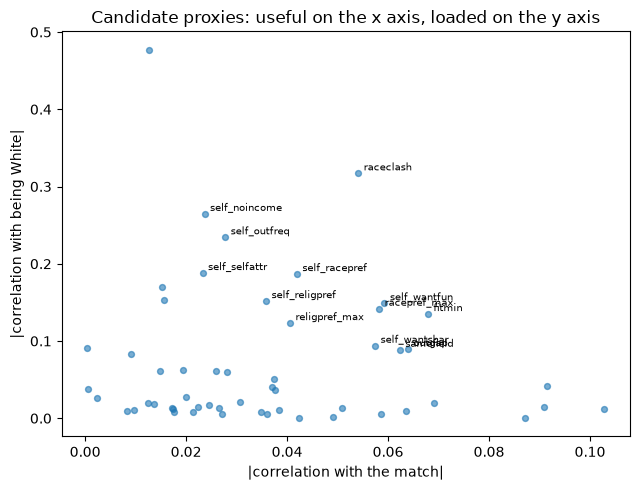

,dependence on the outcome,dependence on ethnicity
variable,,
raceclash,0.054,0.317
self_noincome,0.024,0.265
self_outfreq,0.028,0.235
self_selfattr,0.023,0.188
self_racepref,0.042,0.187
self_religpref,0.036,0.152
self_wantfun,0.059,0.149
racepref_max,0.058,0.142
fitmin,0.068,0.135


In [18]:
SUSPECTS = [c for c in decision_view(table, "her").columns
            if c not in SIDE_CATEGORICAL + ["female"]]
white = (sides.group == "White").astype(int)
her_white = (table.her_race.map(RACE) == "White").astype(int)
candidates = []
for column in SUSPECTS:
    values = decision_view(table, "her")[column]
    ok = values.notna() & table.match.notna()
    candidates.append({"variable": column,
                       "dependence on the outcome": abs(np.corrcoef(values[ok], table.match[ok])[0, 1]),
                       "dependence on ethnicity": abs(np.corrcoef(values[ok], her_white[ok])[0, 1])})

proxies = pd.DataFrame(candidates).set_index("variable").dropna()

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(proxies["dependence on the outcome"], proxies["dependence on ethnicity"], s=18, alpha=0.6)
flagged = proxies[(proxies["dependence on ethnicity"] > 0.08) & (proxies["dependence on the outcome"] > 0.02)]
for name, row in flagged.iterrows():
    ax.annotate(name, (row["dependence on the outcome"], row["dependence on ethnicity"]),
                fontsize=7, xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("|correlation with the match|")
ax.set_ylabel("|correlation with being White|")
ax.set_title("Candidate proxies: useful on the x axis, loaded on the y axis")
plt.tight_layout()
plt.savefig("reports/figures/06_proxies.png", dpi=150)
plt.show()
flagged.sort_values("dependence on ethnicity", ascending=False).round(3)

## What goes on the slide

In [19]:
print(verdicts[["difference (pts)", "parity p (BH)", "conditional p (BH)", "verdict"]].round(4).to_string())
point, low, high = bootstrap_ci(oof, amplification)
print(f"\namplification of the same-background preference: {point:.2f} [{low:.2f}, {high:.2f}]")
print(f"dropping ethnicity and raceclash moves the top decile "
      f"{panel_a.loc['full model', 'top decile']:.3f} -> {panel_a.loc['without either', 'top decile']:.3f}")
print(f"ethnicity stays recoverable from the other columns, up to AUC "
      f"{recovered['AUC predicting it without any ethnicity column'].max():.2f}")
print(f"equivalence at 5 points: "
      f"{(equivalence.loc['5%', 'equivalent'] == 'yes').sum()} of {len(GROUPS) + 1} comparisons")

            difference (pts)  parity p (BH)  conditional p (BH)                                          verdict
Asian                -5.5216         0.0000              0.0000  RED — the gap survives the legitimate variables
White                -0.5291         0.4254              0.1126                        GREEN — no detectable gap
Latino                3.4047         0.0060              0.0030  RED — the gap survives the legitimate variables
Other                 6.7696         0.0000              0.0000  RED — the gap survives the legitimate variables
Black                10.0628         0.0000              0.0000  RED — the gap survives the legitimate variables
mixed pair           -3.3929         0.0005              0.0007  RED — the gap survives the legitimate variables



amplification of the same-background preference: 1.16 [1.03, 1.30]
dropping ethnicity and raceclash moves the top decile 0.298 -> 0.253
ethnicity stays recoverable from the other columns, up to AUC 0.66
equivalence at 5 points: 2 of 6 comparisons
